## Детекция клеток

Ваша задача: обучить YOLO для детекции дрожжевых клеток и микроструктур (см. [07_object_detection.ipynb](../workshops/07_object_detection.ipynb)). Всё необходимое для запуска обучения вы можете взять из ноутбука с практикой, доделать нужно будет самую малость:
- реализовать расчёт Mean Average Precision для всего валидационного сета
- попробовать привести regression loss к виду, который используется в Yolo9000 и YoloV3
- подобрать лучшие размеры якорных рамок с помощью кластеризации

Основная цель: любыми средствами добиться $mAP > 0.6$ на валидации.

Используйте класс `torchmetrics.detection.MeanAveragePrecision` для расчёта $mAP$.

Нас будет интересовать именно значение `map` в словаре со всеми метриками - это mean average precision, усреднённый по всем отсечкам intersection over union в диапазоне $[0.5, 0.95]$ (см. документацию к классу).

При решении можно пользоваться `lightning` или писать цикл обучения вручную. В последнем случае не забудьте вручную отправить модель и батчи на GPU, чтобы обучалось быстрее

### Задание 1 (3 балла). Цикл обучения с расчётом Mean Average Precision

Запустите обучение модели из практики на всём обучающем датасете, выведите значение $mAP$ на валидационном датасете после окончания обучения.

В этом задании добейтесь $mAP > 0.3$, если всё сделано правильно - для этого должно хватать 30-50 эпох.

In [208]:
! wget --no-clobber https://tudatalib.ulb.tu-darmstadt.de/bitstream/handle/tudatalib/3799/yeast_cell_in_microstructures_dataset.zip
! ! test -d yeast_cell_in_microstructures_dataset && unzip yeast_cell_in_microstructures_dataset.zip -d yeast_cell_in_microstructures_dataset

%pip install torchmetrics lightning

import lightning as L
import torch
import torchmetrics
from torch import Tensor, nn
from torch.nn import functional as F

from typing import Type

import torch
from torch import Tensor, nn
from torch.nn import functional as F

from collections import defaultdict
from typing import Callable

import matplotlib.pyplot as plt
import requests
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torch import Tensor, nn
from torch.nn import functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms


from pathlib import Path

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.figure import Figure
from torch import Tensor, nn
from torch.utils.data import DataLoader, Dataset
from torchmetrics.functional.detection import intersection_over_union
from torchvision.ops.boxes import box_convert


File ‘yeast_cell_in_microstructures_dataset.zip’ already there; not retrieving.



In [209]:
torch.manual_seed(42)

In [210]:
def process_yolo_preds(preds: Tensor, rescaled_anchors: Tensor) -> tuple[Tensor, Tensor, Tensor]:
    """
    Преобразование выходов модели в
    1. Логит наличия объекта (вероятность получается применением сигмоиды)
    2. Положение рамки относительно ячейки в формате cxcywh
    3. Логиты классов (вероятности получаются применением softmax)
    """
    rescaled_anchors = rescaled_anchors.view(1, len(rescaled_anchors), 1, 1, 2)
    box_predictions = preds[..., 1:5].clone()

    box_predictions[..., 0:2] = torch.sigmoid(box_predictions[..., 0:2])
    box_predictions[..., 2:] = torch.exp(box_predictions[..., 2:]) * rescaled_anchors

    scores = preds[..., 0:1]
    return scores, box_predictions, preds[..., 5:]

In [211]:
GRID_SIZE = 8
IMAGE_SIZE = 256
ANCHORS = [
    [48, 72],
    [64, 64],
    [72, 48],
]

rescaled_anchors = torch.tensor(ANCHORS).to('cuda') / IMAGE_SIZE * GRID_SIZE

In [212]:
class CNNBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, **kwargs):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, bias=False, **kwargs)
        self.bn = nn.BatchNorm2d(out_channels)
        self.activation = nn.LeakyReLU(0.1)

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        return self.activation(x)

class TinyYOLO(nn.Module):
    def __init__(self, num_classes: int = 2, num_anchors: int = 1, in_channels: int = 1) -> None:
        super().__init__()
        self.num_classes = num_classes
        self.in_channels = in_channels
        self.num_anchors = num_anchors
        self.layers = nn.Sequential(
            CNNBlock(1, 16, kernel_size=3, stride=2, padding=1, dilation=2),
            CNNBlock(16, 32, kernel_size=3, stride=2, padding=1, dilation=2),
            CNNBlock(32, 64, kernel_size=3, stride=2, padding=1, dilation=2),
            CNNBlock(64, 128, kernel_size=3, stride=2, padding=1, groups=8),
            CNNBlock(128, 256, kernel_size=3, stride=1, padding=1, groups=8),
            CNNBlock(256, 256, kernel_size=3, stride=1, padding=1, groups=16),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(256, num_anchors * (num_classes + 5), kernel_size=1)
        )

    def forward(self, x: Tensor) -> Tensor:
        x = self.layers(x)
        B, _, W, H = x.shape
        x = x.view(B, self.num_anchors, self.num_classes + 5, W, H)  # B A F W H
        x = x.permute(0, 1, 3, 4, 2)  # B A W H F
        return x


model = TinyYOLO(in_channels=1, num_anchors=len(ANCHORS), num_classes=2)
print(sum(p.numel() for p in model.parameters()))
model.forward(torch.randn(2, 1, 256, 256)).shape

113029


torch.Size([2, 3, 8, 8, 7])

In [213]:
def iou_wh(wh1: Tensor, wh2: Tensor) -> Tensor:
    # IoU based on width and height of bboxes

    # intersection
    intersection_area = torch.min(wh1[..., 0], wh2[..., 0]) * torch.min(wh1[..., 1], wh2[..., 1])

    # union
    box1_area = wh1[..., 0] * wh1[..., 1]
    box2_area = wh2[..., 0] * wh2[..., 1]
    union_area = box1_area + box2_area - intersection_area

    iou_score = intersection_area / union_area
    return iou_score


def boxes_to_cells(
    boxes: Tensor,
    classes: Tensor,
    rescaled_anchors: Tensor,
    grid_size: int = 8,
    ignore_iou_thresh: float = 0.5,
) -> Tensor:
    """
    Переводит bbox представление в клеточное представление, где каждая рамка -
    (id класса, вероятность нахождения объекта, cx, cy, w, h), а клеточное представление
    имеет размер (batch_size, n_anchors, grid_size, grid_size, 6), в последней размерности
    хранятся признаки ячейки: класс объекта, вероятность объекта, координаты и размеры рамки
    относительно ячейки

    Args:
        boxes (Tensor): тензор со всеми рамками
        classes (Tensor): тензор с id классов объектов
        rescaled_anchors (Tensor): тензор размера (n_anchors, 2) с размерами якорей в долях от размеров ячейки
        grid_size (int): размер сетки,
        ignore_iou_thresh (float, optional): значение IoU для рамок, при котором ячейка,
            занятая более чем одним объектом, будет специально помечена для игнорирования
    """
    targets = torch.zeros((len(rescaled_anchors), grid_size, grid_size, 6))

    # Каждой рамке сопоставляем клетку и наиболее подходящий якорь
    for box, class_label in zip(boxes, classes):
        iou_anchors = iou_wh(box[2:4], rescaled_anchors / grid_size)
        anchor_indices = iou_anchors.argsort(descending=True, dim=0)
        x, y, width, height = box

        # Относим рамку к наиболее подходящему якорю
        has_anchor = False
        for anchor_idx in anchor_indices:
            s = grid_size

            # Определяем клетку, к которой относится рамка
            i, j = int(s * y), int(s * x)
            anchor_taken = targets[anchor_idx, i, j, 0]

            # Проверяем, доступен ли якорная рамка для текущей ячейки
            if not anchor_taken and not has_anchor:
                # Пересчитываем координаты по отношению к клетке
                x_cell, y_cell = s * x - j, s * y - i
                width_cell, height_cell = (width * s, height * s)
                box_coordinates = torch.tensor([x_cell, y_cell, width_cell, height_cell])

                # Заполняем содержимое для выбранной клетки
                targets[anchor_idx, i, j, 0] = 1  # указатель, что в клетке есть объект
                targets[anchor_idx, i, j, 1:5] = box_coordinates
                targets[anchor_idx, i, j, 5] = int(class_label)

                has_anchor = True

            # Если якорь уже выбран, проверим IoU, если больше threshold - пометим клетку -1
            elif not anchor_taken and iou_anchors[anchor_idx] > ignore_iou_thresh:
                targets[anchor_idx, i, j, 0] = -1

    return targets

In [214]:
class YeastDetectionDataset(Dataset):
    def __init__(
        self, subset_dir: Path, anchors: list[tuple[int, int]], image_size: int, grid_size: int = 8
    ) -> None:
        super().__init__()
        self.subset_dir = subset_dir
        self.items = list((self.subset_dir / "inputs").glob("*.pt"))
        # Ignore IoU threshold
        self.ignore_iou_thresh = 0.5
        self.rescaled_anchors = torch.tensor(anchors) / image_size * grid_size
        self.grid_size = grid_size
        self.image_size = image_size

    def __len__(self) -> int:
        return len(self.items)

    def __getitem__(self, index: int) -> tuple[Tensor, Tensor]:
        image_path = self.items[index]
        # load everything
        image = torch.load(image_path, weights_only=True).unsqueeze(0)
        classes = (
            torch.load(self.subset_dir / "classes" / image_path.parts[-1], weights_only=True) + 1
        )
        boxes = torch.load(
            self.subset_dir / "bounding_boxes" / image_path.parts[-1], weights_only=True
        )
        boxes = box_convert(boxes, "xyxy", "cxcywh") / self.image_size

        # convert boxes to cells
        targets = boxes_to_cells(
            boxes, classes, self.rescaled_anchors, self.grid_size, self.ignore_iou_thresh
        )
        return image, targets

In [215]:
train_dataset = YeastDetectionDataset(
    Path("yeast_cell_in_microstructures_dataset/train"), anchors=ANCHORS, image_size=256
)
val_dataset = YeastDetectionDataset(Path("yeast_cell_in_microstructures_dataset/val"), anchors=ANCHORS, image_size=256)

batch_size = 32
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False)

In [216]:
x, y = train_dataset[2]
y.shape

torch.Size([3, 8, 8, 6])

In [217]:
from typing import Callable

from lightning.pytorch.utilities.types import EVAL_DATALOADERS, TRAIN_DATALOADERS
from PIL.Image import Image
from torch.utils.data import DataLoader
from torchvision import datasets, transforms


class Datamodule(L.LightningDataModule):
    def __init__(
        self,
        batch_size: int,
        num_workers: int = 0,
    ):
        super().__init__()
        self.batch_size = batch_size
        self.num_workers = num_workers

    def prepare_data(self) -> None:
        # в этом методе можно сделать предварительную работу, например
        # скачать данные, сделать тяжёлый препроцессинг
        pass

    def setup(self, stage: str) -> None:
        # аргумент `stage` будет приходить из модуля обучения Trainer
        # на стадии обучения (fit) нам нужны оба датасета
        if stage == "fit":
            self.train_dataset = YeastDetectionDataset(Path("yeast_cell_in_microstructures_dataset/train"), anchors=ANCHORS, image_size=256)
            self.val_dataset = YeastDetectionDataset(Path("yeast_cell_in_microstructures_dataset/val"), anchors=ANCHORS, image_size=256)
        # на стадии валидации (validate) - только тестовый
        elif stage == "validate":
            self.val_dataset = YeastDetectionDataset(Path("yeast_cell_in_microstructures_dataset/val"), anchors=ANCHORS, image_size=256)
        else:
            raise NotImplementedError
        # есть ещё стадии `test` и `predict`, но они нам не понадобятся

    def train_dataloader(self) -> TRAIN_DATALOADERS:
        return DataLoader(
            self.train_dataset,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=self.num_workers,
        )

    def val_dataloader(self) -> EVAL_DATALOADERS:
        return DataLoader(
            self.val_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
        )

In [218]:
def cells_to_bboxes(cells: Tensor, rescaled_anchors: Tensor, is_predictions=False) -> Tensor:
    """
    Переводит клеточное представление в bbox представление, где каждая рамка -
    (id класса, вероятность нахождения объекта, cx, cy, w, h), а клеточное представление
    имеет размер (batch_size, n_anchors, grid_size, grid_size, 6), в последней размерности
    хранятся признаки ячейки: класс объекта, вероятность объекта, координаты и размеры рамки
    относительно ячейки

    Args:
        cells (Tensor): тензор размера (batch_size, n_anchors, width, height, 6)
        rescaled_anchors (Tensor): тензор размера (n_anchors, 2) с размерами якорей в долях от размеров ячейки
        is_predictions (bool, optional): являются ли входные ячейки предсказаниями или верной аннотацией.
    """

    if is_predictions:
        scores, box_predictions, logits = process_yolo_preds(cells, rescaled_anchors)
        scores = torch.sigmoid(scores)
        best_class = torch.argmax(logits, dim=-1).unsqueeze(-1) + 1

    else:
        box_predictions = cells[..., 1:5].clone()
        scores = cells[..., 0:1]
        best_class = cells[..., 5:6]

    # масштабируем размер рамок [0, grid_size] -> [0, 1]
    _, _, H, W, _ = cells.shape
    range_y, range_x = torch.meshgrid(
        torch.arange(H, dtype=cells.dtype, device=cells.device),
        torch.arange(W, dtype=cells.dtype, device=cells.device),
        indexing="ij",
    )
    x = torch.cat(
        [
            best_class,
            scores,
            (box_predictions[..., 0:1] + range_x[None, None, :, :, None]) / W,  # X center
            (box_predictions[..., 1:2] + range_y[None, None, :, :, None]) / H,  # Y center
            box_predictions[..., 2:3] / W,  # Width
            box_predictions[..., 3:4] / H,  # Height
        ],
        -1,
    )

    return x.view(-1, 6)

In [219]:
def plot_image(image: Tensor, boxes: Tensor, class_labels: list[str]) -> Figure:
    # назначим цвета для классов
    colour_map = plt.get_cmap("tab20b")
    colors = [colour_map(i) for i in np.linspace(0, 1, len(class_labels))]

    fig, ax = plt.subplots(1)
    ax.imshow(image, cmap="gray")
    h, w = image.shape
    for box in boxes:
        # добавляем прямоугольник
        class_pred = box[0] - 1
        box = box[2:]
        upper_left_x = box[0] - box[2] / 2
        upper_left_y = box[1] - box[3] / 2

        rect = patches.Rectangle(
            (upper_left_x * w, upper_left_y * h),
            box[2] * w,
            box[3] * h,
            linewidth=2,
            edgecolor=colors[int(class_pred)],
            facecolor="none",
        )
        ax.add_patch(rect)

        # добавляем подпись
        ax.text(
            upper_left_x * w,
            upper_left_y * h,
            s=class_labels[int(class_pred)],
            color="white",
            verticalalignment="top",
            bbox={"color": colors[int(class_pred)], "pad": 0},
        )

    return fig

In [220]:
class YOLOLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.mse = nn.MSELoss()
        self.bce = nn.BCEWithLogitsLoss()
        self.cross_entropy = nn.CrossEntropyLoss()

    def forward(self, pred: Tensor, target: Tensor, anchors: Tensor) -> Tensor:
        # ниже входные тензоры будут меняться на месте, так что склонируем их
        pred = pred.clone()
        target = target.clone()

        # разделяем рамки на содержащие объекты и не содержащие
        # NB: ещё могут быть -1, куда отнеслось более 1 объекта - их не учитываем
        obj = target[..., 0] == 1
        no_obj = target[..., 0] == 0

        # преобразуем предсказания bbox
        scores, pred_boxes, logits = process_yolo_preds(pred, anchors)

        # no object loss: кросс-энтропия вместо MSE
        no_object_loss = self.bce(
            (scores[no_obj]),
            (target[..., 0:1][no_obj]),
        )

        # object loss: учим предсказывать IoU
        ious = intersection_over_union(pred_boxes[obj], target[..., 1:5][obj]).detach()
        object_loss = self.mse(scores[obj].sigmoid(), ious * target[..., 0:1][obj])

        # box coordinate loss: логарифмируем размеры рамок перед расчётом MSE
        anchors = anchors.reshape(1, len(anchors), 1, 1, 2)
        pred[..., 1:3] = pred[..., 1:3].sigmoid()
        target[..., 3:5] = torch.log(1e-6 + target[..., 3:5] / anchors)
        box_loss = self.mse(pred[..., 1:5][obj], target[..., 1:5][obj])

        # class loss: здесь всё обычно
        class_loss = self.cross_entropy(logits[obj], target[..., 5][obj].long() - 1)

        # Total loss
        return box_loss + object_loss + no_object_loss + class_loss

In [221]:
from typing import Any

from lightning.pytorch.utilities.types import STEP_OUTPUT
from torchmetrics.detection import MeanAveragePrecision
from torchvision.ops.boxes import nms

def batch2boxes(preds, target):
    predicted_boxes = []
    target_boxes = []
    for i in range(len(target)):
        # получаем предсказанные рамки
        pred_boxes = cells_to_bboxes(preds[i:i+1], rescaled_anchors, is_predictions=True)
        # pred_boxes = pred_boxes[pred_boxes[:, 1] > 0.2]
        # ВАЖНО: делаем non-max suppression ДО расчёта метрик
        pred_boxes = pred_boxes[nms(box_convert(pred_boxes[:, 2:], "cxcywh", "xyxy"), pred_boxes[:, 1], iou_threshold=0.3)]
        predicted_boxes.append(
            dict(
                boxes=pred_boxes[:, 2:],
                scores=pred_boxes[:, 1],
                labels=pred_boxes[:, 0].long(),
            )
        )
        # достаём правильные рамки
        true_boxes = cells_to_bboxes(target[i:i+1], rescaled_anchors)
        true_boxes = true_boxes[true_boxes[:, 1] == 1]

        target_boxes.append(
            dict(
                boxes=true_boxes[:, 2:],
                labels=true_boxes[:, 0].long(),
            )
        )
    return predicted_boxes, target_boxes


class Lit(L.LightningModule):
    def __init__(self, model, loss_fn, lr=0.001, wd=0.01) -> None:
        super().__init__()
        self.model = model
        self.loss_fn = loss_fn
        self.lr = lr
        self.wd = wd
        self.train_metrics = MeanAveragePrecision(iou_type="bbox", box_format="cxcywh", class_metrics=True)
        self.val_metrics = MeanAveragePrecision(iou_type="bbox", box_format="cxcywh", class_metrics=True)

    def training_step(
        self, batch: tuple[Tensor, Tensor], batch_idx: int
    ) -> STEP_OUTPUT:
        x, y = batch
        preds = self.model(x)
        loss = self.loss_fn(preds, y, rescaled_anchors)
        self.log("train_loss", loss, on_epoch=True, on_step=False)
        # self.train_metrics.update(batch2boxes(preds, y))
        # self.log("train_map", self.train_metrics.compute()['map'], on_step=False, on_epoch=True)
        return loss

    def validation_step(
        self, batch: tuple[Tensor, Tensor], batch_idx: int
    ) -> STEP_OUTPUT | None:
        x, y = batch
        preds = self.model(x)
        loss = self.loss_fn(preds, y, rescaled_anchors)
        self.log("val_loss", loss, on_epoch=True, on_step=False)
        self.val_metrics.update(*batch2boxes(preds, y))
        self.log("val_map", self.val_metrics.compute()['map'], on_step=False, on_epoch=True)
        print(self.val_metrics.compute()['map'])
        return {
            "loss": loss,
            "preds": preds,
        }

    def configure_optimizers(self) -> dict[str, Any]:
        optimizer = torch.optim.Adam(self.model.parameters(),
                                     lr=self.lr, weight_decay=self.wd)
        return {
            "optimizer": optimizer
        }

In [222]:
trainer = L.Trainer(
    accelerator="auto",
    max_epochs=40,
    log_every_n_steps=1,
)
lit_module = Lit(
    model=TinyYOLO(in_channels=1, num_classes=2, num_anchors=len(rescaled_anchors)),
    loss_fn=YOLOLoss())
# datamodule = Datamodule(batch_size=32)
trainer.fit(
    lit_module,
    train_loader,
)

INFO: GPU available: True (cuda), used: True
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | model         | TinyYOLO             | 113 K  | train
1 | loss_fn       | YOLOLoss             | 0      | train
2 | train_metrics | MeanAveragePrecision | 0      | train
3 | v

Training: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=40` reached.
INFO: `Trainer.fit` stopped: `max_epochs=40` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=40` reached.


In [223]:
trainer.validate(lit_module, val_loader)

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Validation: |          | 0/? [00:00<?, ?it/s]

tensor(0.5208)
tensor(0.5267)


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         val_loss          │    0.09910283982753754    │
│          val_map          │     0.522858202457428     │
└───────────────────────────┴───────────────────────────┘

[{'val_loss': 0.09910283982753754, 'val_map': 0.522858202457428}]

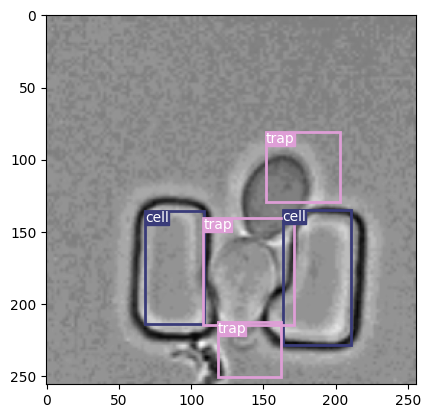

In [235]:
torch.manual_seed(42)

idx = 2

x, y = next(iter(val_loader))
preds = lit_module.model.forward(x)

boxes = cells_to_bboxes(preds[idx].detach().unsqueeze(0), rescaled_anchors.cpu(), is_predictions=True)
boxes = boxes[boxes[:, 1] > 0.3]
boxes = boxes[nms(box_convert(boxes[:, 2:], "cxcywh", "xyxy"), boxes[:, 1], iou_threshold=0.2)]
fig = plot_image(x[idx, 0].to("cpu"), boxes, ["cell", "trap"])
plt.show()

### Задание 2 (2 балла). YoloV3 loss

Мы упоминали, что на практике использовалась не совсем та же самая ошибка, что и в YOLO. В этом задании исправьте в классе YoloLoss ошибку регрессии, приведя её в соответствие с тем, как она описана в статье [YOLOv3: An Incremental Improvement](https://arxiv.org/abs/1804.02767) (см. раздел 2.1. Bounding Box Prediction).

Запустите обучение с изменённой ошибкой, добейтесь $mAP > 0.3$

In [225]:
class YOLOLossV3(nn.Module):
    def __init__(self):
        super().__init__()
        self.mse = nn.MSELoss()
        self.bce = nn.BCEWithLogitsLoss()
        self.cross_entropy = nn.CrossEntropyLoss()

    def forward(self, pred: Tensor, target: Tensor, anchors: Tensor) -> Tensor:
        # ниже входные тензоры будут меняться на месте, так что склонируем их
        pred = pred.clone()
        target = target.clone()

        # разделяем рамки на содержащие объекты и не содержащие
        # NB: ещё могут быть -1, куда отнеслось более 1 объекта - их не учитываем
        obj = target[..., 0] == 1
        no_obj = target[..., 0] == 0

        # преобразуем предсказания bbox
        scores, pred_boxes, logits = process_yolo_preds(pred, anchors)

        # no object loss: кросс-энтропия вместо MSE
        no_object_loss = self.bce(
            (scores[no_obj]),
            (target[..., 0:1][no_obj]),
        )

        # object loss: учим предсказывать IoU
        ious = intersection_over_union(pred_boxes[obj], target[..., 1:5][obj]).detach()
        object_loss = self.mse(scores[obj].sigmoid(), ious * target[..., 0:1][obj])

        # box coordinate loss: логарифмируем размеры рамок перед расчётом MSE
        anchors = anchors.reshape(1, len(anchors), 1, 1, 2)
        pred[..., 1:3] = pred[..., 1:3].sigmoid()
        target[..., 3:5] = torch.log(1e-6 + target[..., 3:5] / anchors)
        box_loss = 0.3 * ((pred[..., 1:5][obj] - target[..., 1:5][obj]) ** 2).sum()

        # class loss: здесь всё обычно
        class_loss = self.cross_entropy(logits[obj], target[..., 5][obj].long() - 1)

        # Total loss
        return box_loss + object_loss + no_object_loss + class_loss

In [226]:
trainer = L.Trainer(
    accelerator="auto",
    max_epochs=40,
    log_every_n_steps=1,
)
lit_module = Lit(
    model=TinyYOLO(in_channels=1, num_classes=2, num_anchors=len(rescaled_anchors)),
    loss_fn=YOLOLossV3(),
    lr=0.01,
    wd=0.1
)
trainer.fit(
    lit_module,
    train_dataloaders=train_loader,
)

INFO: GPU available: True (cuda), used: True
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | model         | TinyYOLO             | 113 K  | train
1 | loss_fn       | YOLOLossV3           | 0      | train
2 | train_metrics | MeanAveragePrecision | 0      | train
3 | v

Training: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=40` reached.
INFO: `Trainer.fit` stopped: `max_epochs=40` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=40` reached.


In [227]:
trainer.validate(lit_module, val_loader)

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Validation: |          | 0/? [00:00<?, ?it/s]

tensor(0.5268)
tensor(0.5351)


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         val_loss          │     2.107497453689575     │
│          val_map          │    0.5297011733055115     │
└───────────────────────────┴───────────────────────────┘

[{'val_loss': 2.107497453689575, 'val_map': 0.5297011733055115}]

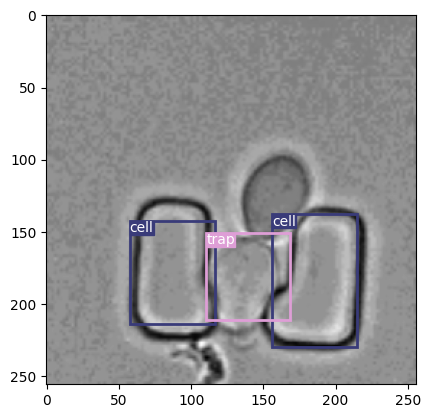

In [228]:
torch.manual_seed(42)

idx = 2

x, y = next(iter(val_loader))
preds = lit_module.model.forward(x)

boxes = cells_to_bboxes(preds[idx].detach().unsqueeze(0), rescaled_anchors.cpu(), is_predictions=True)
boxes = boxes[boxes[:, 1] > 0.4]
boxes = boxes[nms(box_convert(boxes[:, 2:], "cxcywh", "xyxy"), boxes[:, 1], iou_threshold=0.2)]
fig = plot_image(x[idx, 0].to("cpu"), boxes, ["cell", "trap"])
plt.show()

### Задание 3 (3 балла). Выбор anchors с помощью кластеризации

В статье [YOLO9000: Better, Faster, Stronger](https://arxiv.org/abs/1612.08242) в разделе 2. Better. Dimension clusters описан способ выбора anchor boxes через кластеризацию обучающего датасета.

Проделайте то же самое с вашим обучающим датасетом, чтобы выбрать несколько anchor boxes.

В качестве результата выведите получившиеся размеры anchors для # Clusters = 5

In [229]:
from sklearn.cluster import KMeans

rescaled_anchors = torch.tensor(ANCHORS) / IMAGE_SIZE * GRID_SIZE

all_boxes = []
for _, y in train_dataset:
    boxes = cells_to_bboxes(y.unsqueeze(0), rescaled_anchors)
    boxes = boxes[boxes[:, 1] == 1]
    boxes = boxes[:, 4:] * 256

    all_boxes += boxes

all_boxes = np.array(all_boxes)

kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(all_boxes)
ANCHORS = kmeans.cluster_centers_
print(ANCHORS)

rescaled_anchors = torch.tensor(ANCHORS).to('cuda') / IMAGE_SIZE * GRID_SIZE
print(rescaled_anchors)

[[ 70.705284 105.61467 ]
 [ 90.87096   83.258064]
 [ 43.886246  46.880188]
 [ 57.746483  86.80282 ]
 [ 60.147064  63.249954]]
tensor([[2.2095, 3.3005],
        [2.8397, 2.6018],
        [1.3714, 1.4650],
        [1.8046, 2.7126],
        [1.8796, 1.9766]], device='cuda:0')


### Задание 4 (4 балла + бонусы за лучшую точность). Обучите модель


Ваша цель: $mAP > 0.6$ на валидации.

Можете использовать весь арсенал:
- использование множества якорных рамок (сформированных вручную или в результате кластеризации)
- любые изменения функции ошибки
- любые изменения архитектуры модели и регуляризация
- аугментации (вспоминаем `torchvision.transforms` и `albumentations`)
- любая длительность обучения, оптимизатор, расписание для learning rate

Бонусы за повышенную точность:
- **5 баллов**: $mAP > 0.65$
- **1 балл** за каждые следующие $0.01$ (т. е. за $mAP > 0.72$ в этом задании вы получите $4 + 12 = 16$ баллов)

**Важно**: перез запуском обучения зафиксируйте `torch.manual_seed()`

In [240]:
torch.manual_seed(42)
train_dataset = YeastDetectionDataset(
    Path("yeast_cell_in_microstructures_dataset/train"), anchors=ANCHORS, image_size=256
)
val_dataset = YeastDetectionDataset(Path("yeast_cell_in_microstructures_dataset/val"), anchors=ANCHORS, image_size=256)

batch_size = 32
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False)

trainer = L.Trainer(
    accelerator="auto",
    max_epochs=100,
    log_every_n_steps=1,
)
lit_module = Lit(
    model=TinyYOLO(in_channels=1, num_classes=2, num_anchors=len(rescaled_anchors)),
    loss_fn=YOLOLoss(),
    lr=0.004, wd=0.0005
)

trainer.fit(
    lit_module,
    train_loader,
)

INFO: GPU available: True (cuda), used: True
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | model         | TinyYOLO             | 116 K  | train
1 | loss_fn       | YOLOLoss             | 0      | train
2 | train_metrics | MeanAveragePrecision | 0      | train
3 | v

Training: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=100` reached.
INFO: `Trainer.fit` stopped: `max_epochs=100` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.


In [241]:
trainer.validate(lit_module, val_loader)

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Validation: |          | 0/? [00:00<?, ?it/s]

tensor(0.6570)
tensor(0.6633)


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         val_loss          │    0.06762897223234177    │
│          val_map          │    0.6591482162475586     │
└───────────────────────────┴───────────────────────────┘

[{'val_loss': 0.06762897223234177, 'val_map': 0.6591482162475586}]